Upload 2 file  training và test dataset lên đây

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)

df_train = pd.read_csv('training_set_1e-4.txt', sep=' ')
X_train_raw = df_train.drop(columns=['RID', 'Phenotype']).values
y_train = df_train['Phenotype'].values

feature_names = df_train.drop(columns=['RID', 'Phenotype']).columns.tolist()

print(f"X_train shape: {X_train_raw.shape}")
print(f"y_train shape: {y_train.shape}")


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(solver='saga', max_iter=1000, class_weight='balanced', random_state=42))
])

param_grid = {
   'log_reg__penalty': ['l1'], # Lasso
   'log_reg__C': [0.05,0.1,0.2,0.5,1,2,4],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_raw, y_train)

best_params = grid_search.best_params_
best_index = grid_search.best_index_

best_mean = grid_search.cv_results_['mean_test_score'][best_index]
best_std  = grid_search.cv_results_['std_test_score'][best_index]

print(f"{best_params}")

# read test file
df_test = pd.read_csv('holdout_set_1e-4.txt', sep=' ')
X_test_raw = df_test.drop(columns=['RID', 'Phenotype']).values
y_test = df_test['Phenotype'].values

best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test_raw)
y_pred_proba = best_pipeline.predict_proba(X_test_raw)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")
print(f"Confusion Matrix:\n{cm}")


best_log_reg = best_pipeline.named_steps['log_reg']
weights = best_log_reg.coef_[0]

feature_importance = pd.DataFrame({
    'Gene_Variant': feature_names,
    'Weight': weights,
    'Abs_Weight': np.abs(weights)
}).sort_values(by='Abs_Weight', ascending=False)


best_penalty = best_params['log_reg__penalty']
best_c = best_params['log_reg__C']
output_csv = f'Feature_Importance_{best_penalty}_c={best_c}.csv'
feature_importance.drop(columns=['Abs_Weight']).to_csv(output_csv, index=False)
print(f"Final weight saved to : {output_csv}")



In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Control', 'Alzheimer'],
    cmap='Blues', values_format='d'
)
plt.savefig('plots/adni_1e-4_lasso_0.1_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 700x600 with 0 Axes>

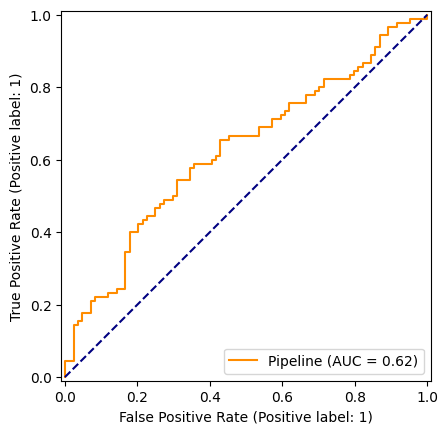

In [ ]:
# ROC Curve
plt.figure(figsize=(7, 6))
RocCurveDisplay.from_estimator(best_pipeline, X_test_raw, y_test, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.savefig('plots/adni_1e-4_lasso_0.1_roc_curve.pdf', dpi=300, bbox_inches='tight')
plt.show()

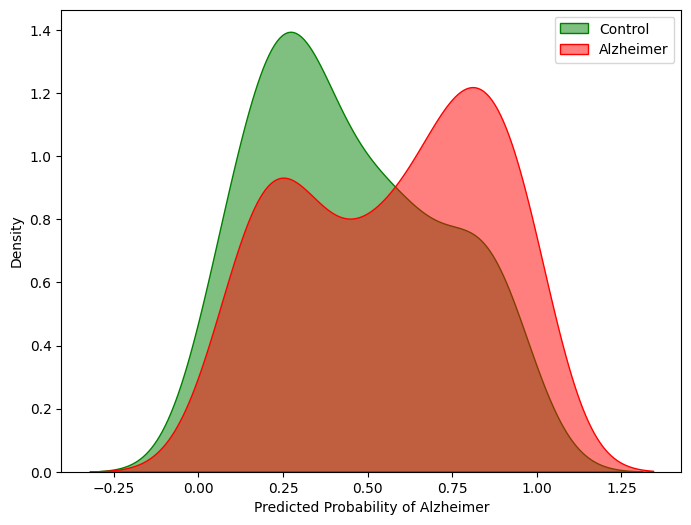

In [ ]:
# Risk Score Distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(y_pred_proba[y_test == 0], label='Control', fill=True, color='green', alpha=0.5)
sns.kdeplot(y_pred_proba[y_test == 1], label='Alzheimer', fill=True, color='red', alpha=0.5)
plt.xlabel('Predicted Probability of Alzheimer')
plt.ylabel('Density')
plt.legend()
plt.savefig('plots/adni_1e-4_lasso_0.1_risk_score_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()